In [119]:
import argparse
import random
import sys

import numpy as np
import pandas as pd
from PIL import Image
from matplotlib import cm

eps = sys.float_info.epsilon
scale_up = 1
res = [2160, 1080]
random.seed(3)

In [145]:
populations_df = pd.read_csv("../out/populations.csv")
parent_df = pd.read_csv("../out/parent_tree.csv")

In [146]:
def build_tree(parent_df, ids, rootId):
    tree = { cloneId: list(children) for cloneId in ids if \
        len(children := parent_df.loc[parent_df["ParentId"] == cloneId, "ChildId"]) > 0}   
    if -1 not in tree:
        tree[-1] = [rootId]
    return tree

In [147]:
pop_sizes = populations_df[["Gen", "Pop"]].groupby("Gen", as_index=False).sum()
parents = parent_df["ParentId"].unique()
children = parent_df["ChildId"].unique()
root_list = np.setdiff1d(parents, children)
if len(root_list) != 1:
    raise Exception("Failed to determine root. There must be exactly one node with no parent in the parent tree.")
rootId = root_list[0]
ids = np.concatenate([[rootId], children])
tree = build_tree(parent_df, ids, rootId)

In [152]:
print(f"Evolutionary tree has: {len(tree)} nodes; {len(ids) - len(tree)} leafs; rootId {rootId}")

Evolutionary tree has: 25 nodes; 55 leafs; rootId 340


In [149]:
def line_from_data(px_row_orig, width):
    result = []
    pop_total = sum(row_it[0] for row_it in px_row_orig)
    px_row = [[px_row_orig[i][0] * width / pop_total, px_row_orig[i][1]] for i in range(len(px_row_orig))]
    contr = 1.0
    index = 0
    new_px = np.zeros(4)
    while index < len(px_row):
        if px_row[index][0] >= eps:
            factor = contr if px_row[index][0] >= contr else px_row[index][0]
            px_row[index][0] -= factor
            contr -= factor
            new_px += px_row[index][1] * factor
            if contr < eps:
                contr = 1.0
                result.append(new_px)
                new_px = np.zeros(4)
        else:
            index += 1
    if len(result) < width:
        result.append(new_px + contr * np.ones(4) * .5) # Adde gray to the last pixel if needed
    return result

In [150]:
# Taken from https://stackoverflow.com/questions/3160699/python-progress-bar
def progressbar(it, prefix="", size=60, file=sys.stdout):
    count = len(it)
    def show(j):
        x = int(size*j/count)
        file.write("%s[%s%s] %i/%i\r" % (prefix, "#"*x, "."*(size-x), j, count))
        file.flush()        
    show(0)
    for i, item in enumerate(it):
        yield item
        show(i+1)
    file.write("\n")
    file.flush()

Legend:


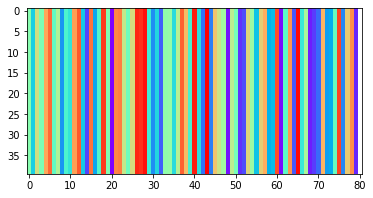

In [159]:
# Create Colors
cols = cm.rainbow(np.linspace(0, 1, len(ids))).tolist()
random.shuffle(cols)
col_map = {ids[i]: np.array(list(map(lambda x: (int)(x * 255), cols[i]))) for i in range(len(ids))}
col_map[-1] = np.ones(4) # Root is white 

# Display test colors
px_row = [[1, col_map[id]] for id in col_map]
test_px = line_from_data(px_row, len(px_row))
array = np.array([test_px] * (len(px_row) // 2), dtype=np.uint8)
new_image = Image.fromarray(array)
print("Legend:")
plt.imshow(new_image)

In [137]:
def get_pop_dict(pops_df, gen, max_pop, normalize):
    test_pop = pops_df[pops_df["Gen"] == gen]
    pop_dict = { test_pop["Id"].iat[i]: test_pop["Pop"].iat[i] for i in range(len(test_pop))}
    if not normalize:
        pop_count = pops_df[pops_df["Gen"] == gen]["Pop"].sum()
        remainder = max_pop - pop_count
        pop_dict[-1] = remainder
    return pop_dict

def rec_descend(tree, pop_dict, cloneId):
    res = []
    if cloneId in tree:
        if cloneId in pop_dict:
            pop = pop_dict[cloneId] / 2
            res += [(pop, cloneId)]
            for childId in tree[cloneId]:
                res += rec_descend(tree, pop_dict, childId) 
            res += [(pop, cloneId)]
        else: 
            for childId in tree[cloneId]:
                res += rec_descend(tree, pop_dict, childId) 
    elif cloneId in pop_dict:
        return [(pop_dict[cloneId], cloneId)]
    return res

def get_image_pixels(tree, rootId, pop_df, col_map, max_pop, breath, first_gen, last_gen, normalize = True):    
    img_pixels = []
    for i in progressbar(range(first_gen, last_gen + 1), "Converting generation: "):
        pop_dict = get_pop_dict(pop_df, i, max_pop, normalize)
        if len(pop_dict) > 0:
            id_rows = rec_descend(tree, pop_dict, rootId if normalize else -1)
            pixel_row = [(id_row[0], col_map[id_row[1]]) for id_row in id_rows]
        else: 
            pixel_row = [(-1, np.ones(4) * 127)]
        line_px = line_from_data(pixel_row, breath)
        img_pixels.append(line_px)
    return img_pixels

def pixels_to_img(img_pixels, res):
    px_array = np.array(img_pixels, dtype=np.uint8)
    new_image = Image.fromarray(px_array).transpose(Image.ROTATE_270).transpose(Image.FLIP_LEFT_RIGHT)
    resized = new_image.resize(res)
    return resized

In [135]:
# # Test
test_pop_d = get_pop_dict(populations_df, 0, max_pop, True)
line = rec_descend(tree, test_pop_d, rootId)

In [141]:
last_gen = pop_sizes["Gen"].max()
max_pop = pop_sizes["Pop"].max()
img_pixels = get_image_pixels(tree, rootId, populations_df, col_map, max_pop, res[1] * scale_up, 666, last_gen, True)

Converting generation: [############################################################] 297/297


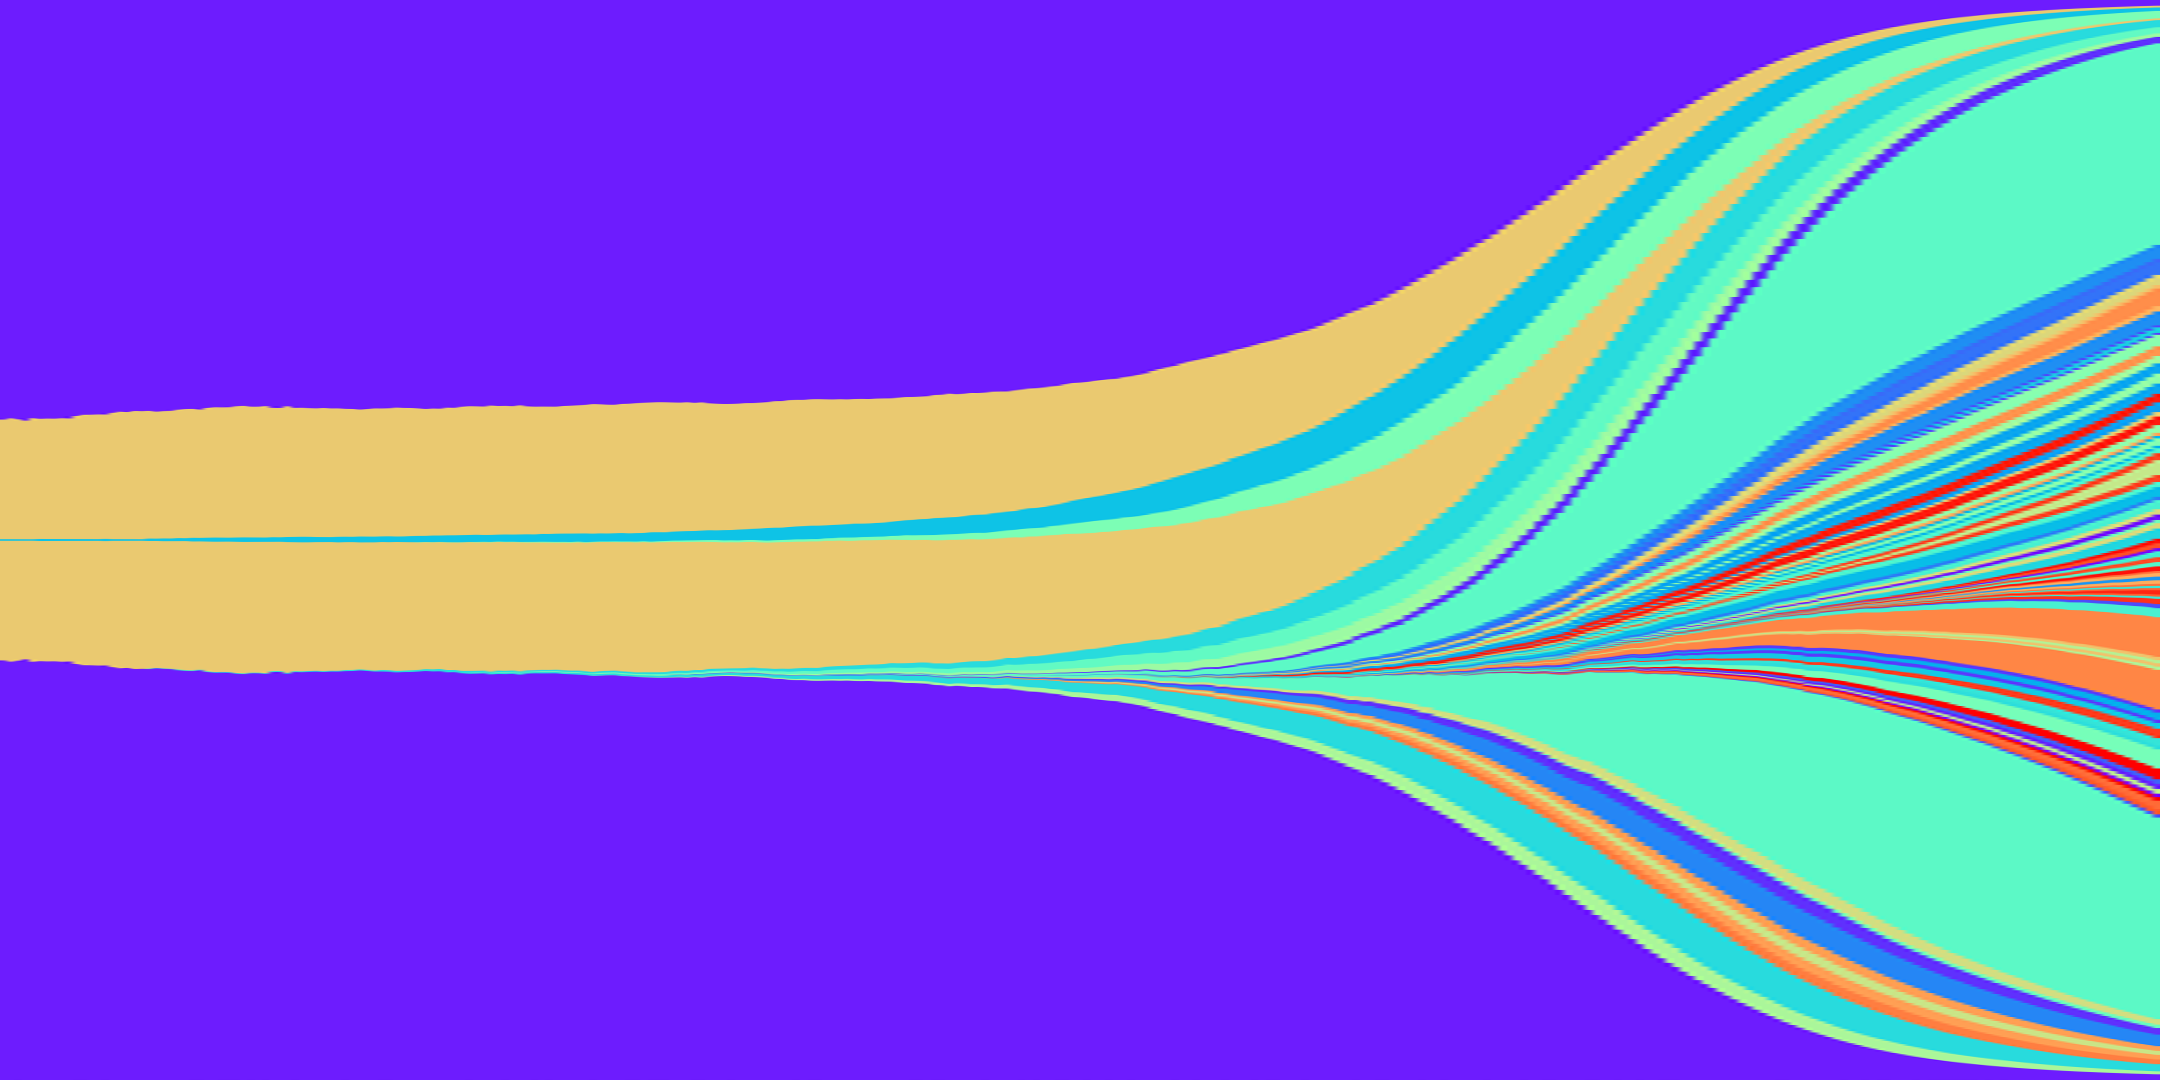

In [142]:
pixels_to_img(img_pixels, res)